In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import numpy as np
import cv2
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K
from math import ceil

print("TF version:", tf.__version__)

TF version: 2.19.0


In [ ]:
# Image & mask settings
IMG_HEIGHT = 256
IMG_WIDTH  = 256
N_CHANNELS = 3      # we'll keep 3 channels to match your augmentation code
N_CLASSES  = 1

# Paths (CHANGE THESE!)
NORMAL_IMG_DIR = "/content/drive/MyDrive/Colab/PHD/few-shot/Cerebellar/data_cell_new_200/image"
NORMAL_MASK_DIR = "/content/drive/MyDrive/Colab/PHD/few-shot/Cerebellar/data_cell_new_200/ground_truth"
ABN_IMG_DIR = "/content/drive/MyDrive/Colab/PHD/few-shot/Cerebellar/Cell_Dandy/image"
ABN_MASK_DIR = "/content/drive/MyDrive/Colab/PHD/few-shot/Cerebellar/Cell_Dandy/ground-truth"

BATCH_SIZE = 4

In [ ]:
def mlvum(image, neighborhood_size=7, k=0):
    """
    Maximum Local Variation-based Unsharp Masking (MLVUM)

    image: BGR uint8 image (as read by cv2.imread)
    neighborhood_size: neighborhood / blur sigma (e.g. 7, 11, 15)
    k: threshold on Laplacian magnitude to decide 'low-variation' regions
    """
    # Ensure uint8 BGR
    if image.dtype != np.uint8:
        image = image.astype(np.uint8)

    # 1) Local variation via Laplacian on grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    local_var = cv2.Laplacian(gray, cv2.CV_64F, ksize=neighborhood_size)

    # Use absolute variation (edges are large magnitude, flat regions small)
    low_variation_mask = np.abs(local_var) < k    # bool mask (H,W)

    # 2) Unsharp masking
    blurred  = cv2.GaussianBlur(image, (0, 0), neighborhood_size)
    sharpened = cv2.addWeighted(image, 1.5, blurred, -0.5, 0)

    # 3) Enhance only low-variation regions
    enhanced_image = np.where(low_variation_mask[..., None], sharpened, image)

    return enhanced_image


In [ ]:
def load_image(path, target_size=(IMG_HEIGHT, IMG_WIDTH)):
    bgr = cv2.imread(path, cv2.IMREAD_COLOR)
    bgr = cv2.resize(bgr, target_size)
    bgr_enh = mlvum(bgr, neighborhood_size=15, k=0)
    rgb = cv2.cvtColor(bgr_enh, cv2.COLOR_BGR2RGB)
    rgb = rgb.astype(np.float32) / 255.0
    return rgb

def load_mask(path, target_size=(IMG_HEIGHT, IMG_WIDTH)):
    mask = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, target_size, interpolation=cv2.INTER_NEAREST)
    mask = (mask > 127).astype(np.float32)
    mask = np.expand_dims(mask, axis=-1)
    return mask

def get_image_mask_pairs(img_dir, mask_dir):
    """
    Build (image_path, mask_path) pairs.

    Handles cases like:
      image: 1.png
      mask:  1_G.png

    and also falls back to same-name mask if it exists:
      image: 1.png
      mask:  1.png
    """
    img_files = sorted([
        f for f in os.listdir(img_dir)
        if f.lower().endswith((".png", ".jpg", ".jpeg", ".tif"))
    ])

    pairs = []
    for f in img_files:
        img_path = os.path.join(img_dir, f)

        # 1) same-name candidate
        same_name_mask = os.path.join(mask_dir, f)

        # 2) name with "_G" before extension (e.g. 1.png -> 1_G.png)
        base, ext = os.path.splitext(f)
        g_name_mask = os.path.join(mask_dir, base + "_G" + ext)

        if os.path.exists(same_name_mask):
            mask_path = same_name_mask
        elif os.path.exists(g_name_mask):
            mask_path = g_name_mask
        else:
            print("Warning: mask not found for", img_path)
            continue

        pairs.append((img_path, mask_path))

    return pairs


def build_arrays_from_pairs(pairs, indices):
    X, y = [], []
    for i in indices:
        img_path, mask_path = pairs[i]
        X.append(load_image(img_path))
        y.append(load_mask(mask_path))  # no n_classes here
    return np.array(X), np.array(y)


In [ ]:
normal_pairs = get_image_mask_pairs(NORMAL_IMG_DIR, NORMAL_MASK_DIR)   # ~200
abn_pairs    = get_image_mask_pairs(ABN_IMG_DIR, ABN_MASK_DIR)         # ~80

print("Normal samples:", len(normal_pairs))
print("Abnormal samples:", len(abn_pairs))

Normal samples: 200
Abnormal samples: 79


In [ ]:
#Train/val/test split (separate, then merged)


def split_indices(n, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15, seed=42):
    rng = np.random.RandomState(seed)
    indices = np.arange(n)
    rng.shuffle(indices)
    n_train = int(n * train_ratio)
    n_val   = int(n * val_ratio)
    train_idx = indices[:n_train]
    val_idx   = indices[n_train:n_train+n_val]
    test_idx  = indices[n_train+n_val:]
    return train_idx, val_idx, test_idx

# Normal
n_normal = len(normal_pairs)
tr_n_idx, val_n_idx, test_n_idx = split_indices(n_normal)

# Abnormal
n_abn = len(abn_pairs)
tr_a_idx, val_a_idx, test_a_idx = split_indices(n_abn)

def build_arrays_from_pairs(pairs, indices):
    X = []
    y = []
    for i in indices:
        img_path, mask_path = pairs[i]
        X.append(load_image(img_path))
        y.append(load_mask(mask_path))
    return np.array(X), np.array(y)

# Normal sets
Xn_train, yn_train = build_arrays_from_pairs(normal_pairs, tr_n_idx)
Xn_val,   yn_val   = build_arrays_from_pairs(normal_pairs, val_n_idx)
Xn_test,  yn_test  = build_arrays_from_pairs(normal_pairs, test_n_idx)

# Abnormal sets
Xa_train, ya_train = build_arrays_from_pairs(abn_pairs, tr_a_idx)
Xa_val,   ya_val   = build_arrays_from_pairs(abn_pairs, val_a_idx)
Xa_test,  ya_test  = build_arrays_from_pairs(abn_pairs, test_a_idx)

print("Normal_X train/val/test:", Xn_train.shape, Xn_val.shape, Xn_test.shape)
print("Normal_Y train/val/test:", yn_train.shape, yn_val.shape, yn_test.shape)

print("Abn_X    train/val/test:", ya_train.shape, ya_val.shape, ya_test.shape)
print("Abn_Y    train/val/test:", Xa_train.shape, Xa_val.shape, Xa_test.shape)

Normal_X train/val/test: (140, 256, 256, 3) (30, 256, 256, 3) (30, 256, 256, 3)
Normal_Y train/val/test: (140, 256, 256, 1) (30, 256, 256, 1) (30, 256, 256, 1)
Abn_X    train/val/test: (55, 256, 256, 1) (11, 256, 256, 1) (13, 256, 256, 1)
Abn_Y    train/val/test: (55, 256, 256, 3) (11, 256, 256, 3) (13, 256, 256, 3)


In [ ]:
#Handle imbalance (200 vs 80)



def oversample_minority(X_major, y_major, X_minor, y_minor):
    n_major = len(X_major)
    n_minor = len(X_minor)
    factor = ceil(n_major / n_minor)
    X_minor_rep = np.repeat(X_minor, factor, axis=0)
    y_minor_rep = np.repeat(y_minor, factor, axis=0)
    X_minor_rep = X_minor_rep[:n_major]
    y_minor_rep = y_minor_rep[:n_major]
    return X_major, y_major, X_minor_rep, y_minor_rep

Xn_train_bal, yn_train_bal, Xa_train_bal, ya_train_bal = oversample_minority(
    Xn_train, yn_train, Xa_train, ya_train
)

print("After oversampling abnormal:")
print("Normal train:", Xn_train_bal.shape)
print("Abn   train:", Xa_train_bal.shape)

# Concatenate to form final train
X_train = np.concatenate([Xn_train_bal, Xa_train_bal], axis=0)
y_train = np.concatenate([yn_train_bal, ya_train_bal], axis=0)

# For validation, we usually do NOT oversample – just combine as-is
X_val = np.concatenate([Xn_val, Xa_val], axis=0)
y_val = np.concatenate([yn_val, ya_val], axis=0)

print("Train total:", X_train.shape, y_train.shape)
print("Val   total:", X_val.shape, y_val.shape)


After oversampling abnormal:
Normal train: (140, 256, 256, 3)
Abn   train: (140, 256, 256, 3)
Train total: (280, 256, 256, 3) (280, 256, 256, 1)
Val   total: (41, 256, 256, 3) (41, 256, 256, 1)


In [ ]:
def apply_random_augmentation(image, mask):
    # 1. Random Flip
    if np.random.rand() > 0.5:
        image = np.fliplr(image)
        mask = np.fliplr(mask)

    # 2. Random Morphological Op (Pick ONE randomly)
    if np.random.rand() > 0.5:
        ops = [cv2.MORPH_DILATE, cv2.MORPH_ERODE, cv2.MORPH_OPEN, cv2.MORPH_CLOSE]
        op = np.random.choice(ops)
        kernel = np.ones((3,3), np.uint8)
        mask_uint8 = (mask * 255).astype(np.uint8)
        mask = cv2.morphologyEx(mask_uint8, op, kernel)
        mask = (mask > 127).astype(np.float32)[..., np.newaxis]

    # 3. Random Zoom
    if np.random.rand() > 0.5:
        scale = np.random.uniform(1.0, 1.2)
        h, w = image.shape[:2]
        new_h, new_w = int(h * scale), int(w * scale)
        image = cv2.resize(image, (new_w, new_h))
        mask = cv2.resize(mask, (new_w, new_h), interpolation=cv2.INTER_NEAREST)
        # Crop back to 256x256
        start_h = (new_h - h) // 2
        start_w = (new_w - w) // 2
        image = image[start_h:start_h+h, start_w:start_w+w, :]
        mask = mask[start_h:start_h+h, start_w:start_w+w, np.newaxis]

    return image, mask


def train_generator_fixed(images, masks, batch_size):
    num_samples = len(images)
    while True:
        indices = np.random.permutation(num_samples)
        for i in range(0, num_samples, batch_size):
            batch_indices = indices[i:i+batch_size]
            b_imgs, b_msks = [], []
            for idx in batch_indices:
                img, msk = apply_random_augmentation(images[idx], masks[idx])
                b_imgs.append(img); b_msks.append(msk)
            yield np.array(b_imgs), np.array(b_msks)

In [ ]:
# Create the generator
train_gen = train_generator_fixed(X_train, y_train, BATCH_SIZE)

# Val set stays as a tf.data.Dataset (this is fine!)
val_gen = tf.data.Dataset.from_tensor_slices((X_val, y_val)) \
                         .batch(BATCH_SIZE) \
                         .cache() \
                         .prefetch(buffer_size=tf.data.AUTOTUNE)

# If you want the model to see 4 different augmented versions of
# your training set every epoch:
AUG_FACTOR = 4

steps_per_epoch = (len(X_train) * AUG_FACTOR) // BATCH_SIZE
print("Steps per epoch:", steps_per_epoch)

Steps per epoch: 280


# CerDW-MobileNet model in Keras

Now the fun part: encoder + multi-scale context + decoder with attention.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras import backend as K
import numpy as np

# Configuration
IMG_HEIGHT = 256
IMG_WIDTH = 256
N_CHANNELS = 3


# ---------- Small building block: depthwise conv + LayerNorm + ReLU ----------
def dw_conv_ln_relu(x, filters, kernel_size=3, strides=1, dilation_rate=1):
    """Depthwise separable convolution with LayerNorm and ReLU"""
    # Depthwise conv
    x = layers.DepthwiseConv2D(
        kernel_size,
        strides=strides,
        padding='same',
        dilation_rate=dilation_rate,
        use_bias=False
    )(x)
    x = layers.LayerNormalization(axis=-1)(x)
    x = layers.ReLU()(x)

    # Pointwise conv
    x = layers.Conv2D(
        filters,
        1,
        padding='same',
        use_bias=False
    )(x)
    x = layers.LayerNormalization(axis=-1)(x)
    x = layers.ReLU()(x)

    return x


# ---------- Shape–Texture Block ----------
def shape_texture_block(x, filters):
    """
    Your original Shape-Texture block that captures both texture and edge information
    """
    # Texture branch
    t = dw_conv_ln_relu(x, filters)

    # Shape / edge branch: average across channels -> 1 channel
    s = layers.Lambda(lambda z: K.mean(z, axis=-1, keepdims=True))(x)

    # Sobel filters for edge detection
    sobel_x = np.array([[ -1, 0, 1],
                        [ -2, 0, 2],
                        [ -1, 0, 1]], dtype='float32').reshape((3,3,1,1))
    sobel_y = np.array([[ -1,-2,-1],
                        [  0, 0, 0],
                        [  1, 2, 1]], dtype='float32').reshape((3,3,1,1))

    sx = layers.Conv2D(
        1, 3,
        padding='same',
        use_bias=False,
        trainable=False,
        kernel_initializer=tf.constant_initializer(sobel_x)
    )(s)
    sy = layers.Conv2D(
        1, 3,
        padding='same',
        use_bias=False,
        trainable=False,
        kernel_initializer=tf.constant_initializer(sobel_y)
    )(s)

    # Safe edge magnitude
    edge_mag = layers.Lambda(lambda z: tf.sqrt(z[0]**2 + z[1]**2 + 1e-6))([sx, sy])

    # Combine original features with edge map
    se = layers.Concatenate(axis=-1)([x, edge_mag])
    se = dw_conv_ln_relu(se, filters)

    # Fuse texture + shape branches
    out = layers.Concatenate(axis=-1)([t, se])
    out = layers.Conv2D(filters, 1, padding='same', use_bias=False)(out)
    out = layers.LayerNormalization(axis=-1)(out)
    out = layers.ReLU()(out)

    return out


# ---------- Multi-Scale Context Module (bottleneck) ----------
def multi_scale_context_module(x, filters):
    """
    Multi-Scale Context Module with dilated convolutions
    FIXED: Uses Keras layers only (no TensorFlow ops)
    """
    # 3 parallel depthwise convs with different dilation rates
    b1 = dw_conv_ln_relu(x, filters, kernel_size=3, dilation_rate=1)
    b2 = dw_conv_ln_relu(x, filters, kernel_size=3, dilation_rate=3)
    b3 = dw_conv_ln_relu(x, filters, kernel_size=3, dilation_rate=5)

    # Global context branch
    gp = layers.GlobalAveragePooling2D()(x)        # (B, C)
    gp = layers.Dense(filters, activation='relu')(gp)
    gp = layers.Dense(filters, activation='linear')(gp)
    gp = layers.Reshape((1, 1, filters))(gp)       # (B,1,1,F)

    # FIXED: Use Keras Resizing layer instead of tf.image.resize
    spatial_height = x.shape[1]
    spatial_width = x.shape[2]

    if spatial_height is None or spatial_width is None:
        # Fallback for dynamic shapes
        gp = layers.UpSampling2D(size=(8, 8), interpolation='bilinear')(gp)
    else:
        gp = layers.Resizing(spatial_height, spatial_width, interpolation='bilinear')(gp)

    # Concatenate multi-scale branches + global context
    concat = layers.Concatenate(axis=-1)([b1, b2, b3, gp])  # (B,H,W,4F)
    out = layers.Conv2D(filters, 1, padding='same', use_bias=False)(concat)
    out = layers.LayerNormalization(axis=-1)(out)
    out = layers.ReLU()(out)

    return out


# ---------- Attention Skip Fusion ----------
def attention_skip_fusion(dec, enc, filters):
    """
    Attention-based skip connection fusion

    Args:
        dec: decoder feature map (B, H, W, C_dec)
        enc: encoder skip feature (B, H, W, C_enc)
        filters: number of output filters after fusion
    """
    # 1) Channel attention uses both dec+enc to compute context
    concat = layers.Concatenate(axis=-1)([dec, enc])   # (B,H,W,C_dec+C_enc)
    gap = layers.GlobalAveragePooling2D()(concat)      # (B, C_dec+C_enc)

    # 2) Attention weights for decoder features
    C_dec = int(dec.shape[-1])
    hidden = max(C_dec // 2, 8)

    a = layers.Dense(hidden, activation='relu')(gap)
    a = layers.Dense(C_dec, activation='sigmoid')(a)
    a = layers.Reshape((1, 1, C_dec))(a)               # (B,1,1,C_dec)

    # 3) Apply attention on decoder feature
    dec_att = layers.Multiply()([dec, a])              # (B,H,W,C_dec)

    # 4) Fuse with encoder skip and refine
    fused = layers.Concatenate(axis=-1)([dec_att, enc])  # (B,H,W,C_dec+C_enc)
    fused = dw_conv_ln_relu(fused, filters)

    return fused


# ---------- Channel Adapter ----------
def channel_adapter(x, target_filters):
    """
    Adapt feature map channels to target dimension
    """
    x = layers.Conv2D(target_filters, 1, padding='same', use_bias=False)(x)
    x = layers.LayerNormalization(axis=-1)(x)
    x = layers.ReLU()(x)
    return x


# ---------- Helper function to get output shape ----------
def get_output_shape(layer):
    """Safely get output shape from a layer"""
    try:
        if hasattr(layer, 'output_shape'):
            return layer.output_shape
        elif hasattr(layer, 'output'):
            return layer.output.shape
        else:
            return None
    except:
        return None


# ---------- MAIN MODEL: Hybrid CerDW with MobileNetV3 Encoder ----------
def build_hybrid_cerdw_mobilenet(input_shape=(256, 256, 3)):
    """
    Hybrid segmentation model:

    ENCODER: Pre-trained MobileNetV3-Small (ImageNet weights)
    DECODER: Custom architecture with Shape-Texture blocks, Multi-Scale Context, Attention Skip Fusion

    Args:
        input_shape: Input image shape (height, width, channels)

    Returns:
        Keras Model for binary segmentation
    """

    inputs = layers.Input(shape=input_shape)

    # ==================== ENCODER: Pre-trained MobileNetV3-Small ====================
    print("Loading MobileNetV3-Small with ImageNet weights...")

    backbone = tf.keras.applications.MobileNetV3Small(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet',
        include_preprocessing=True
    )

    # Find layers with specific spatial resolutions
    print(f"Extracting skip connections from MobileNetV3 ({len(backbone.layers)} layers)...")

    # We need layers with these spatial sizes: 128x128, 64x64, 32x32, 16x16, 8x8
    target_sizes = [128, 64, 32, 16, 8]
    skip_outputs = []

    # Search for layers with matching spatial dimensions
    for target_h in target_sizes:
        found = False
        # Search backwards to get the last layer with this resolution
        for layer in reversed(backbone.layers):
            shape = get_output_shape(layer)
            if shape is not None and len(shape) == 4:
                h, w = shape[1], shape[2]
                if h == target_h and w == target_h:
                    skip_outputs.append(layer.output)
                    print(f"  ✓ {target_h}x{target_h}: '{layer.name}' -> {shape}")
                    found = True
                    break

        if not found:
            print(f"  ✗ {target_h}x{target_h}: Not found")

    # If spatial matching didn't work, use carefully selected indices
    if len(skip_outputs) != 5:
        print("\n⚠ Spatial matching incomplete, using verified indices...")
        skip_outputs = []

        # These specific indices give us the correct spatial resolutions
        # For 256x256 input: 128x128, 64x64, 32x32, 16x16, 8x8
        verified_indices = [
            8,    # 128x128
            16,   # 64x64
            40,   # 32x32
            80,   # 16x16
            152   # 8x8
        ]

        for idx in verified_indices:
            try:
                layer = backbone.layers[idx]
                skip_outputs.append(layer.output)
                shape = get_output_shape(layer)
                print(f"  Layer {idx}: '{layer.name}' -> {shape}")
            except IndexError:
                print(f"  ✗ Layer {idx}: Index out of range")

    if len(skip_outputs) != 5:
        raise ValueError(
            f"ERROR: Could not extract 5 skip connections.\n"
            f"Only found {len(skip_outputs)} layers.\n"
            f"TensorFlow version: {tf.__version__}"
        )

    print("✓ Successfully extracted 5 skip connections!")

    encoder = models.Model(
        inputs=backbone.input,
        outputs=skip_outputs,
        name='mobilenetv3_encoder'
    )

    # Get encoder features
    encoder_features = encoder(inputs)
    e1_mob, e2_mob, e3_mob, e4_mob, x_mob = encoder_features

    # Print shapes for debugging
    print("\nEncoder output shapes:")
    print(f"  e1: {e1_mob.shape}")
    print(f"  e2: {e2_mob.shape}")
    print(f"  e3: {e3_mob.shape}")
    print(f"  e4: {e4_mob.shape}")
    print(f"  x (bottleneck): {x_mob.shape}")

    # ==================== ADAPT ENCODER FEATURES ====================
    print("\nAdapting encoder features to decoder dimensions...")
    e1 = channel_adapter(e1_mob, 24)   # 128x128 x 24
    e2 = channel_adapter(e2_mob, 32)   # 64x64 x 32
    e3 = channel_adapter(e3_mob, 48)   # 32x32 x 48
    e4 = channel_adapter(e4_mob, 64)   # 16x16 x 64
    x = channel_adapter(x_mob, 96)     # 8x8 x 96

    # ==================== BOTTLENECK: Multi-Scale Context Module ====================
    b = multi_scale_context_module(x, 96)

    # ==================== DECODER: Custom Architecture ====================
    print("Building decoder with custom architecture...")

    # Stage 1: 8x8 -> 16x16
    d = layers.UpSampling2D(size=(2, 2), interpolation='bilinear')(b)
    print(f"After upsample 1: {d.shape}, e4: {e4.shape}")
    d = attention_skip_fusion(d, e4, 64)
    d = shape_texture_block(d, 64)

    # Stage 2: 16x16 -> 32x32
    d = layers.UpSampling2D(size=(2, 2), interpolation='bilinear')(d)
    print(f"After upsample 2: {d.shape}, e3: {e3.shape}")
    d = attention_skip_fusion(d, e3, 48)
    d = shape_texture_block(d, 48)

    # Stage 3: 32x32 -> 64x64
    d = layers.UpSampling2D(size=(2, 2), interpolation='bilinear')(d)
    print(f"After upsample 3: {d.shape}, e2: {e2.shape}")
    d = attention_skip_fusion(d, e2, 32)
    d = shape_texture_block(d, 32)

    # Stage 4: 64x64 -> 128x128
    d = layers.UpSampling2D(size=(2, 2), interpolation='bilinear')(d)
    print(f"After upsample 4: {d.shape}, e1: {e1.shape}")
    d = attention_skip_fusion(d, e1, 24)
    d = shape_texture_block(d, 24)

    # Stage 5: 128x128 -> 256x256
    d = layers.UpSampling2D(size=(2, 2), interpolation='bilinear')(d)
    d = dw_conv_ln_relu(d, 24)

    # ==================== SEGMENTATION HEAD ====================
    outputs = layers.Conv2D(
        1,
        1,
        padding='same',
        activation='sigmoid',
        name='segmentation_output'
    )(d)

    # ==================== BUILD FINAL MODEL ====================
    model = models.Model(
        inputs=inputs,
        outputs=outputs,
        name="Hybrid_CerDW_MobileNetV3"
    )

    print("\n✅ Model built successfully!")
    return model


# ---------- Build and test ----------

    # Build model
model = build_hybrid_cerdw_mobilenet(
        input_shape=(IMG_HEIGHT, IMG_WIDTH, N_CHANNELS))

model.summary()


# Total params: 1,192,749 (4.55 MB)
# Trainable params: 1,180,565 (4.50 MB)
# Non-trainable params: 12,184 (47.59 KB)

Loading MobileNetV3-Small with ImageNet weights...


/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:452: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


Extracting skip connections from MobileNetV3 (157 layers)...
  ✓ 128x128: 'activation_18' -> (None, 128, 128, 16)
  ✓ 64x64: 're_lu_58' -> (None, 64, 64, 72)
  ✓ 32x32: 'activation_19' -> (None, 32, 32, 96)
  ✓ 16x16: 'activation_29' -> (None, 16, 16, 288)
  ✓ 8x8: 'activation_35' -> (None, 8, 8, 576)
✓ Successfully extracted 5 skip connections!

Encoder output shapes:
  e1: (None, 128, 128, 16)
  e2: (None, 64, 64, 72)
  e3: (None, 32, 32, 96)
  e4: (None, 16, 16, 288)
  x (bottleneck): (None, 8, 8, 576)

Adapting encoder features to decoder dimensions...
Building decoder with custom architecture...
After upsample 1: (None, 16, 16, 96), e4: (None, 16, 16, 64)
After upsample 2: (None, 32, 32, 64), e3: (None, 32, 32, 48)
After upsample 3: (None, 64, 64, 48), e2: (None, 64, 64, 32)
After upsample 4: (None, 128, 128, 32), e1: (None, 128, 128, 24)

✅ Model built successfully!


Model: "Hybrid_CerDW_MobileNetV3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv3_encoder │ [(None, 128, 128, │    939,120 │ input_layer_2[0]… │
│ (Functional)        │ 16), (None, 64,   │            │                   │
│                     │ 64, 72), (None,   │            │                   │
│                     │ 32, 32, 96),      │            │                   │
│                     │ (None, 16, 16,    │            │                   │
│                     │ 288), (None, 8,   │            │                   │
│                     │ 8, 576)]          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_38 (Conv2D)  │ (None, 8, 8, 96)  │     55,296 │ mobilenetv3_enco… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 8, 8, 96)  │        192 │ conv2d_38[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_74 (ReLU)     │ (None, 8, 8, 96)  │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d_16 │ (None, 8, 8, 96)  │        864 │ re_lu_74[0][0]    │
│ (DepthwiseConv2D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d_17 │ (None, 8, 8, 96)  │        864 │ re_lu_74[0][0]    │
│ (DepthwiseConv2D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d_18 │ (None, 8, 8, 96)  │        864 │ re_lu_74[0][0]    │
│ (DepthwiseConv2D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 8, 8, 96)  │        192 │ depthwise_conv2d… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 8, 8, 96)  │        192 │ depthwise_conv2d… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 8, 8, 96)  │        192 │ depthwise_conv2d… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 96)        │          0 │ re_lu_74[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_75 (ReLU)     │ (None, 8, 8, 96)  │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_77 (ReLU)     │ (None, 8, 8, 96)  │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_79 (ReLU)     │ (None, 8, 8, 96)  │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 96)        │      9,312 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_39 (Conv2D)  │ (None, 8, 8, 96)  │      9,216 │ re_lu_75[0][0]    │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,192,749 (4.55 MB)

 Trainable params: 1,180,565 (4.50 MB)

 Non-trainable params: 12,184 (47.59 KB)

In [ ]:
#MERTICS
from tensorflow.keras import backend as K

def jaccard_index(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

def dice_coefficient(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

# Precision
def precision_metric(y_true, y_pred, smooth=1e-6):
    y_pred_bin = K.round(K.clip(y_pred, 0, 1))
    y_true_bin = K.round(K.clip(y_true, 0, 1))
    true_positives = K.sum(y_true_bin * y_pred_bin)
    predicted_positives = K.sum(y_pred_bin)
    return (true_positives + smooth) / (predicted_positives + smooth)

# Recall
def recall_metric(y_true, y_pred, smooth=1e-6):
    y_pred_bin = K.round(K.clip(y_pred, 0, 1))
    y_true_bin = K.round(K.clip(y_true, 0, 1))
    true_positives = K.sum(y_true_bin * y_pred_bin)
    possible_positives = K.sum(y_true_bin)
    return (true_positives + smooth) / (possible_positives + smooth)

# Accuracy
def accuracy_metric(y_true, y_pred):
    y_pred_bin = K.round(K.clip(y_pred, 0, 1))
    y_true_bin = K.round(K.clip(y_true, 0, 1))
    return K.mean(K.equal(y_true_bin, y_pred_bin))


model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='binary_crossentropy',
    metrics=[jaccard_index, dice_coefficient, precision_metric,
              recall_metric, accuracy_metric]
)


In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_dice_coefficient',
    patience=25,                # CHANGE 1: Increase from 10 to 25
    mode='max',
    restore_best_weights=True,
    min_delta=0.0001,           # CHANGE 2: Define a tiny threshold
    start_from_epoch=20,        # CHANGE 3: Delay the start of monitoring
    verbose=1
)


checkpoint = tf.keras.callbacks.ModelCheckpoint(
    'best_model.keras',
    monitor='val_dice_coefficient',
    save_best_only=True,
    mode='max'
)


In [ ]:
EPOCHS = 50

history = model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    epochs=EPOCHS,
    validation_data=val_gen,
    verbose=1,
    callbacks=[checkpoint, early_stop]
)


Epoch 1/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 179s 201ms/step - accuracy_metric: 0.9559 - dice_coefficient: 0.0761 - jaccard_index: 0.0396 - loss: 0.4411 - precision_metric: 0.1594 - recall_metric: 2.4816e-04 - val_accuracy_metric: 0.9615 - val_dice_coefficient: 0.0589 - val_jaccard_index: 0.0304 - val_loss: 0.2143 - val_precision_metric: 1.0000 - val_recall_metric: 1.2144e-10
Epoch 2/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 14s 48ms/step - accuracy_metric: 0.9568 - dice_coefficient: 0.0593 - jaccard_index: 0.0306 - loss: 0.2041 - precision_metric: 1.0000 - recall_metric: 9.2199e-11 - val_accuracy_metric: 0.9615 - val_dice_coefficient: 0.0458 - val_jaccard_index: 0.0234 - val_loss: 0.1652 - val_precision_metric: 1.0000 - val_recall_metric: 1.2144e-10
Epoch 3/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 14s 48ms/step - accuracy_metric: 0.9582 - dice_coefficient: 0.1117 - jaccard_index: 0.0620 - loss: 0.1594 - precision_metric: 0.9774 - recall_metric: 0.0506 - val_accuracy_metric: 0.9615 - val_dice_coefficient: 0.0

In [ ]:
model.save("/content/drive/MyDrive/Cerebellar/model.h5")

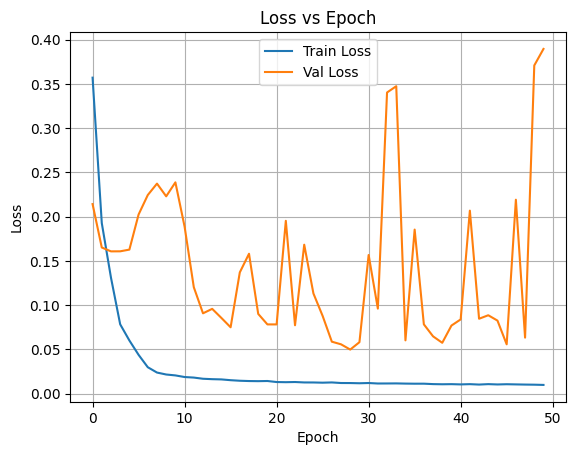

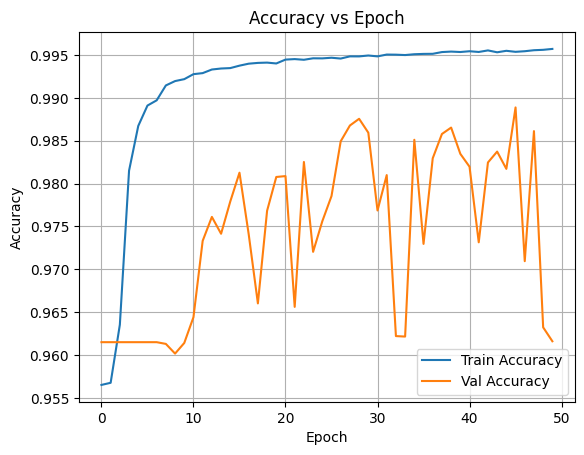

In [ ]:
import matplotlib.pyplot as plt


plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs Epoch')
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(history.history['accuracy_metric'], label='Train Accuracy')
plt.plot(history.history['val_accuracy_metric'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epoch')
plt.legend()
plt.grid(True)
plt.show()


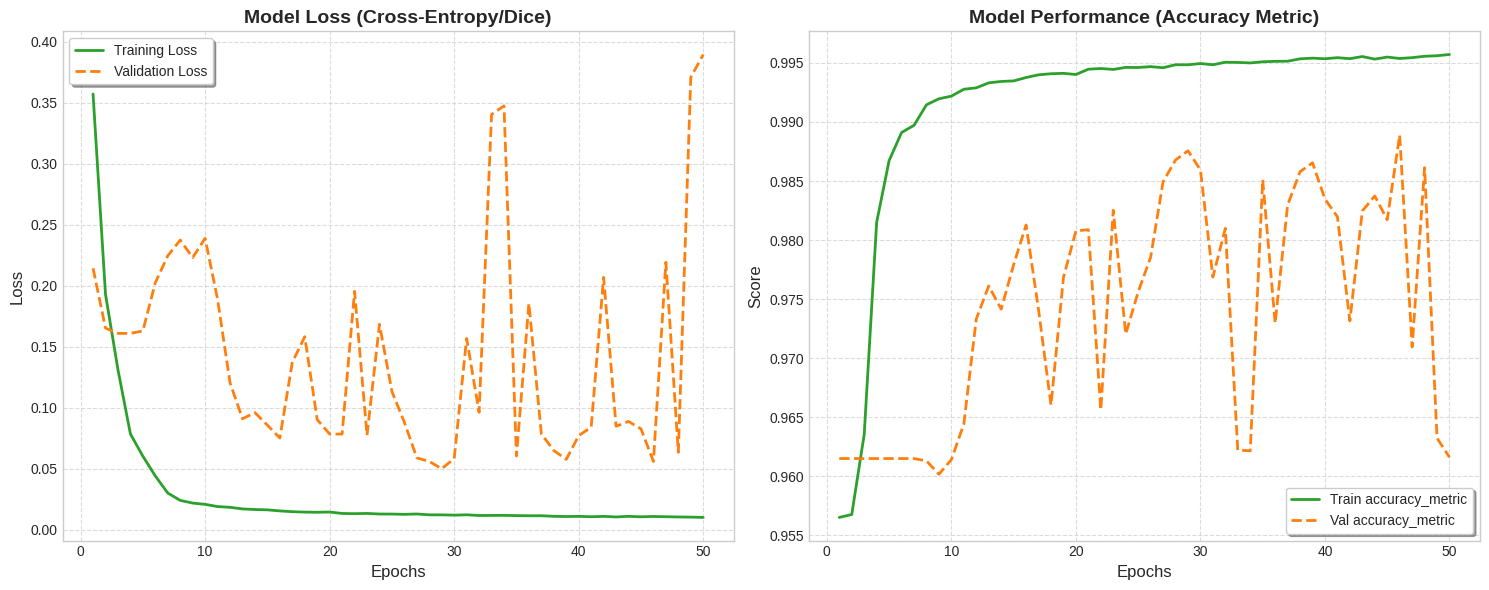

In [ ]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    # Professional styling settings
    plt.style.use('seaborn-v0_8-whitegrid') # Clean background
    epochs = range(1, len(history.history['loss']) + 1)

    # Identify the metric key (handles 'accuracy', 'acc', or 'dice_coefficient')
    metric_keys = [k for k in history.history.keys() if 'loss' not in k and 'val' not in k]
    main_metric = metric_keys[0] if metric_keys else None

    # Create a figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # --- PLOT 1: LOSS ---
    ax1.plot(epochs, history.history['loss'],
             color='#2ca02c', linestyle='-', linewidth=2, label='Training Loss')
    if 'val_loss' in history.history:
        ax1.plot(epochs, history.history['val_loss'],
                 color='#ff7f0e', linestyle='--', linewidth=2, label='Validation Loss')

    ax1.set_title('Model Loss (Cross-Entropy/Dice)', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epochs', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.legend(frameon=True, shadow=True)
    ax1.grid(True, linestyle='--', alpha=0.7)

    # --- PLOT 2: METRIC (DICE/ACCURACY) ---
    if main_metric:
        train_metric = history.history[main_metric]
        val_metric_key = 'val_' + main_metric

        # Professional Colors: Emerald Green and Deep Orange
        ax2.plot(epochs, train_metric,
                 color='#2ca02c', linestyle='-', linewidth=2, label=f'Train {main_metric}')

        if val_metric_key in history.history:
            ax2.plot(epochs, history.history[val_metric_key],
                     color='#ff7f0e', linestyle='--', linewidth=2, label=f'Val {main_metric}')

        ax2.set_title(f'Model Performance ({main_metric.replace("_", " ").title()})',
                     fontsize=14, fontweight='bold')
        ax2.set_xlabel('Epochs', fontsize=12)
        ax2.set_ylabel('Score', fontsize=12)
        ax2.legend(frameon=True, shadow=True)
        ax2.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

# Call the function after your model.fit()
plot_training_history(history)

In [ ]:
def make_test_dataset(X, y, batch_size=BATCH_SIZE):
    return tf.data.Dataset.from_tensor_slices((X, y)) \
                .batch(batch_size) \
                .prefetch(buffer_size=tf.data.AUTOTUNE)

test_normal_ds = make_test_dataset(Xn_test, yn_test)
test_abn_ds    = make_test_dataset(Xa_test, ya_test)

print("Normal test metrics:")
model.evaluate(test_normal_ds, verbose=1)

print("Abnormal (Dandy-Walker) test metrics:")
model.evaluate(test_abn_ds, verbose=1)


Normal test metrics:
8/8 ━━━━━━━━━━━━━━━━━━━━ 27s 4s/step - accuracy_metric: 0.9912 - dice_coefficient: 0.8654 - jaccard_index: 0.7659 - loss: 0.0311 - precision_metric: 0.8558 - recall_metric: 0.9210
Abnormal (Dandy-Walker) test metrics:
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy_metric: 0.9813 - dice_coefficient: 0.7853 - jaccard_index: 0.6469 - loss: 0.0758 - precision_metric: 0.8152 - recall_metric: 0.7909


[0.07703891396522522,
 0.6353222131729126,
 0.7767770886421204,
 0.7903428673744202,
 0.8007367849349976,
 0.979827880859375]

In [ ]:
import matplotlib.pyplot as plt

def plot_triplet(image, gt_mask, pred_mask, suptitle=""):
    """
    image: (H,W,3)
    gt_mask: (H,W,1) or (H,W)
    pred_mask: (H,W,1) or (H,W)
    """
    # squeeze channels for display
    img_disp = image[..., 0]  # ultrasound is grayscale in all 3 channels
    gt_disp  = np.squeeze(gt_mask)
    pr_disp  = np.squeeze(pred_mask)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    if suptitle:
        fig.suptitle(suptitle, fontsize=14)

    axes[0].imshow(img_disp, cmap='gray')
    axes[0].set_title("Image")
    axes[0].axis('off')

    axes[1].imshow(gt_disp, cmap='gray', vmin=0, vmax=1)
    axes[1].set_title("Ground Truth")
    axes[1].axis('off')

    axes[2].imshow(pr_disp, cmap='gray', vmin=0, vmax=1)
    axes[2].set_title("Predicted Mask")
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()


In [ ]:
def show_examples(model, X, Y, n=3, title_prefix=""):
    """
    model: trained segmentation model
    X: images (N,H,W,3)
    Y: masks  (N,H,W,1)
    n: number of examples to show
    """
    n = min(n, len(X))
    indices = np.random.choice(len(X), size=n, replace=False)

    # get predictions
    X_batch = X[indices]
    Y_batch = Y[indices]

    preds = model.predict(X_batch, batch_size=1, verbose=0)
    preds_bin = (preds > 0.5).astype(np.float32)

    for i, idx in enumerate(indices):
        suptitle = f"{title_prefix} sample #{idx}"
        plot_triplet(
            X_batch[i],
            Y_batch[i],
            preds_bin[i],
            suptitle=suptitle
        )


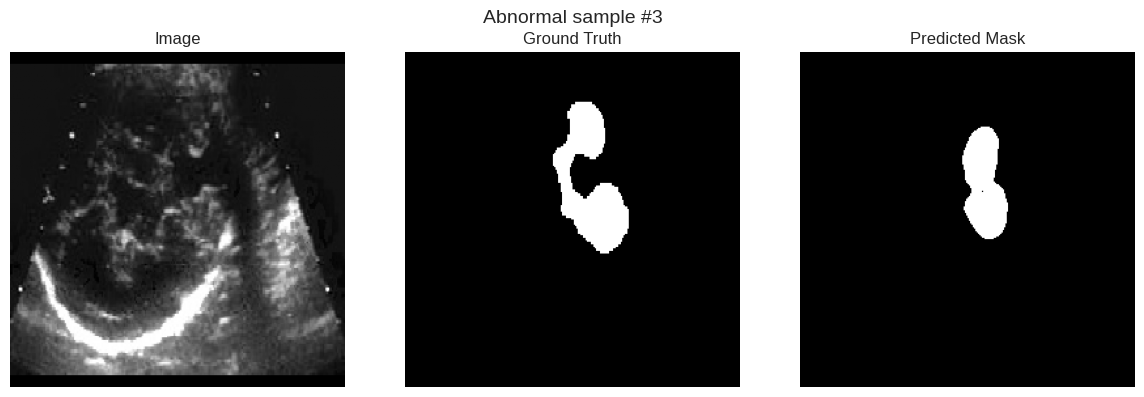

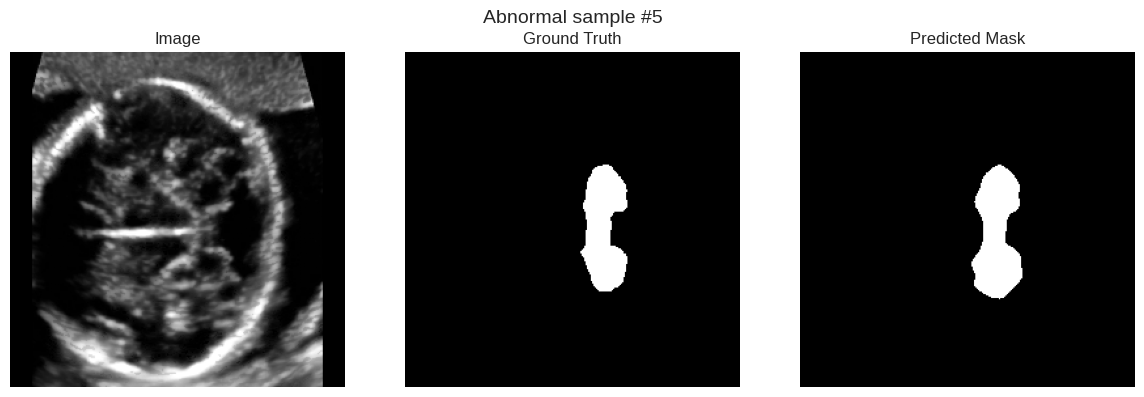

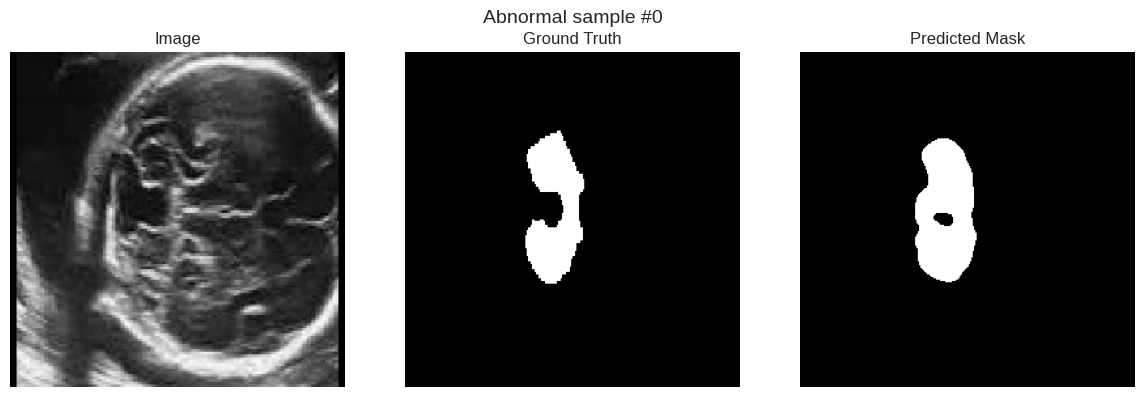

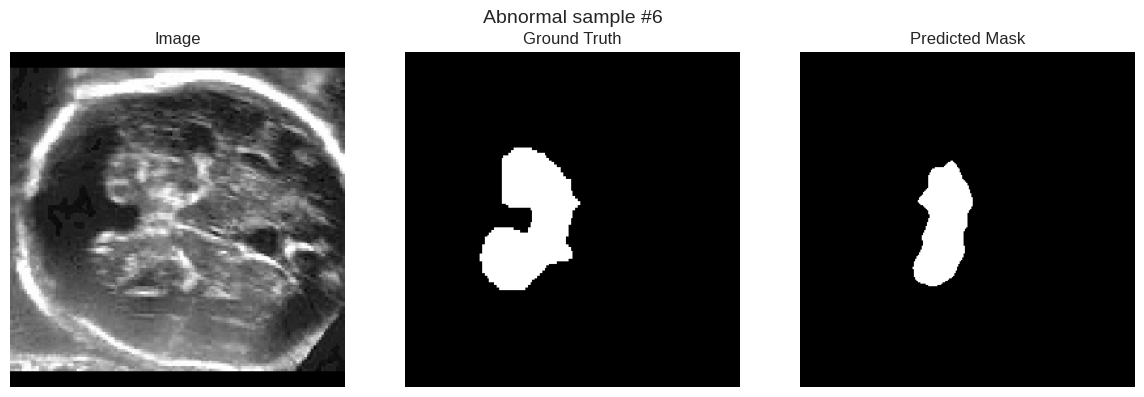

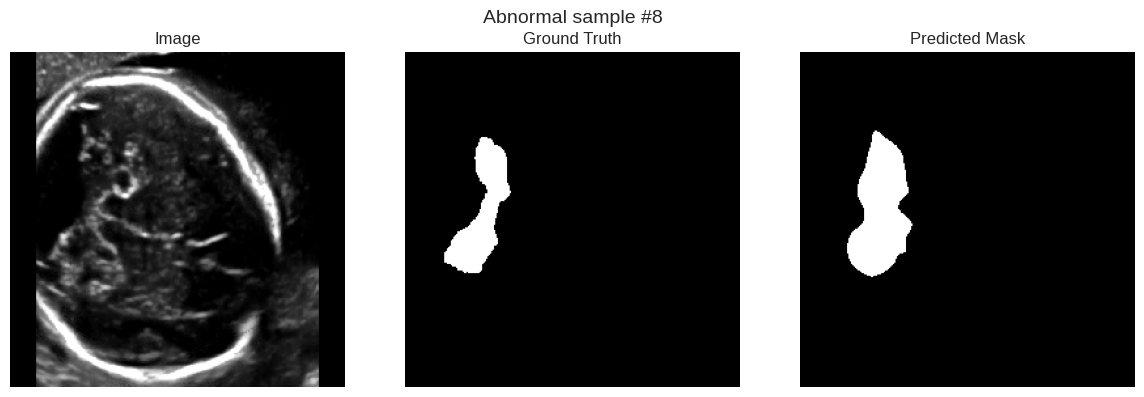

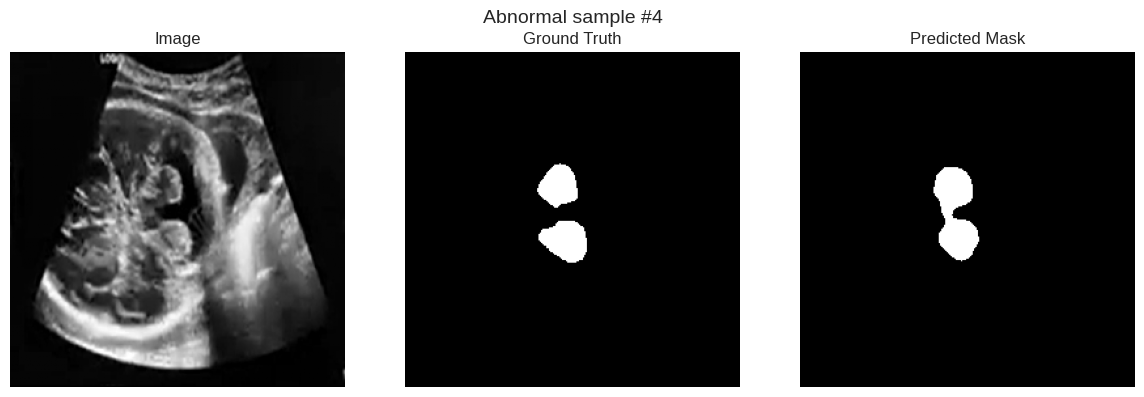

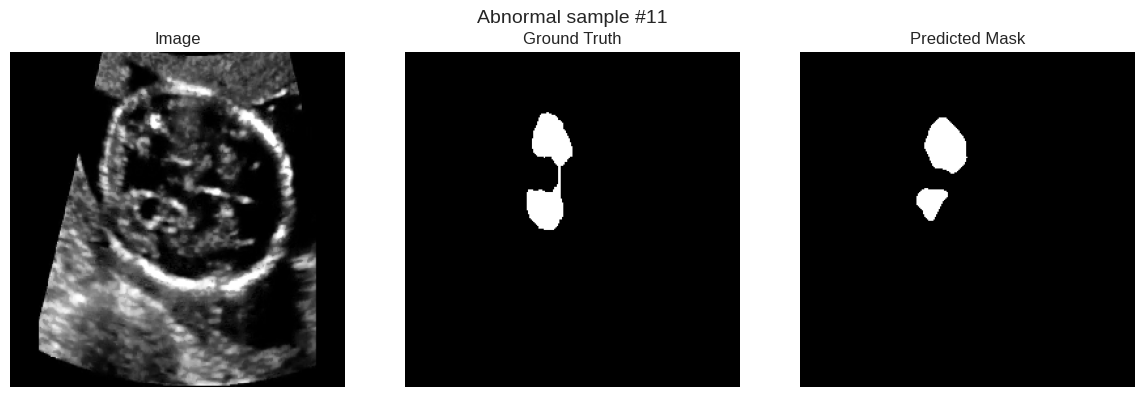

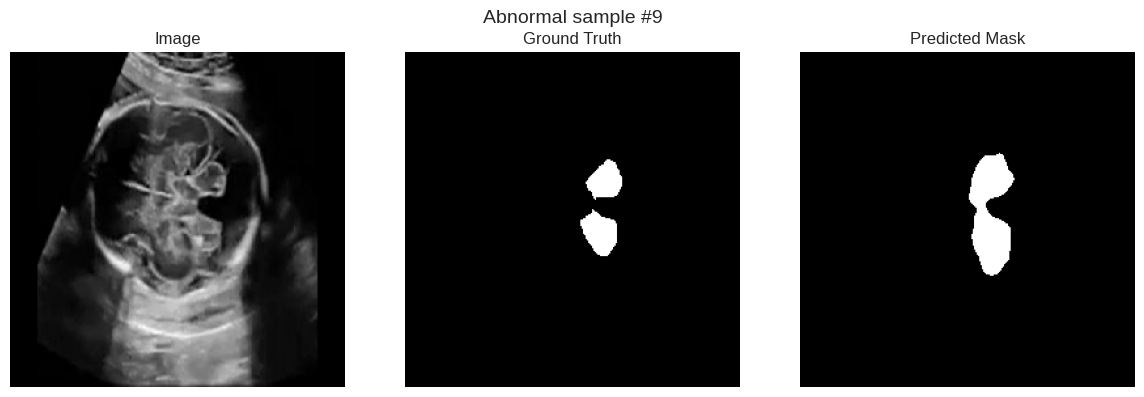

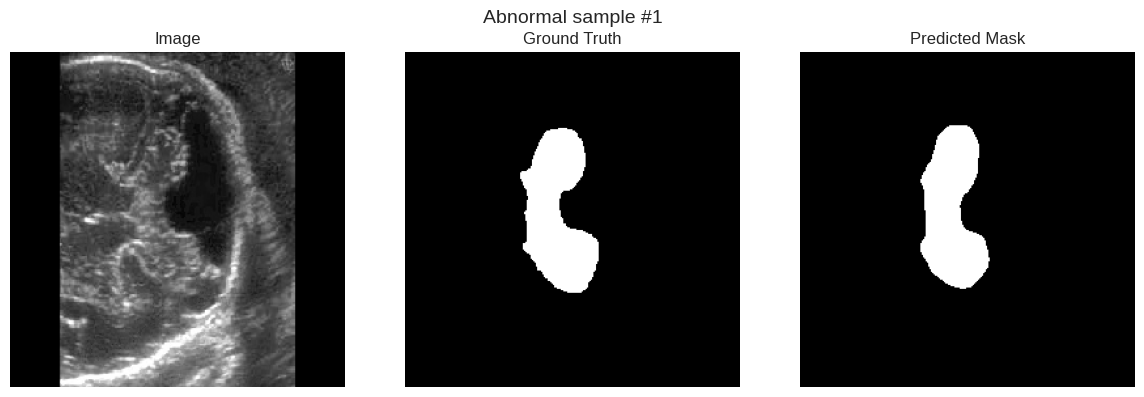

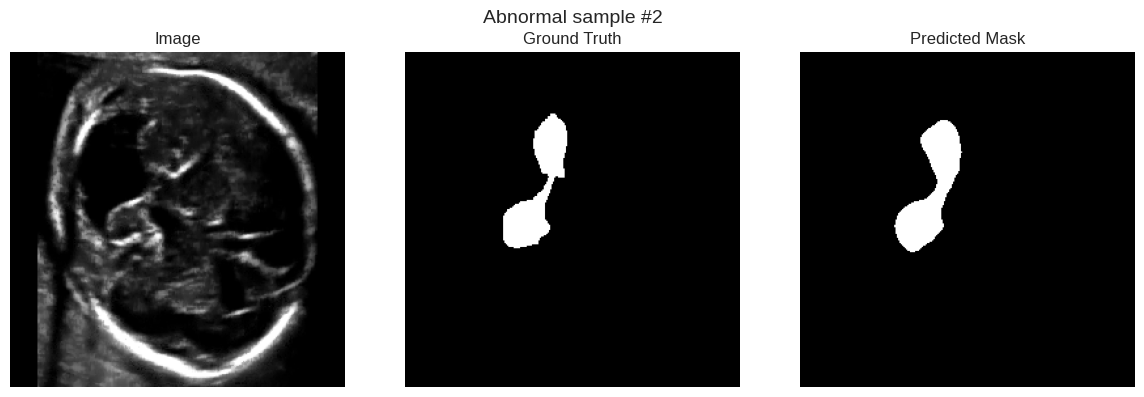

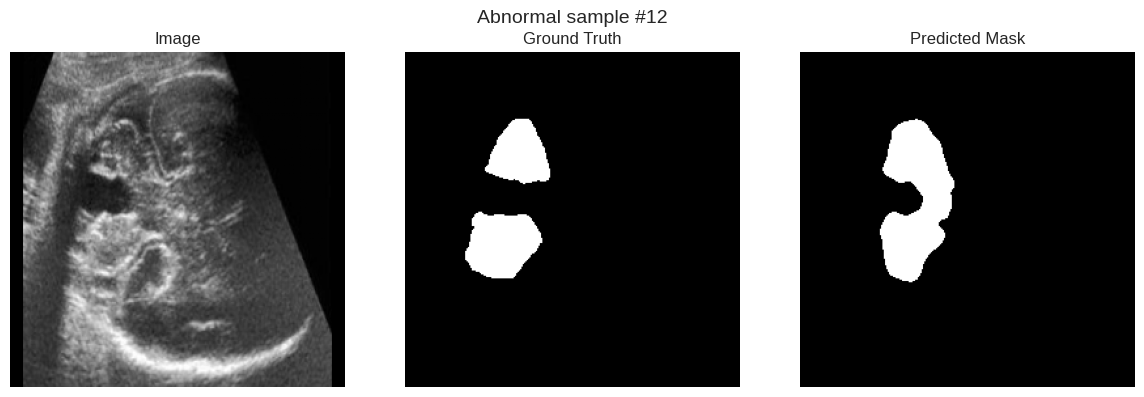

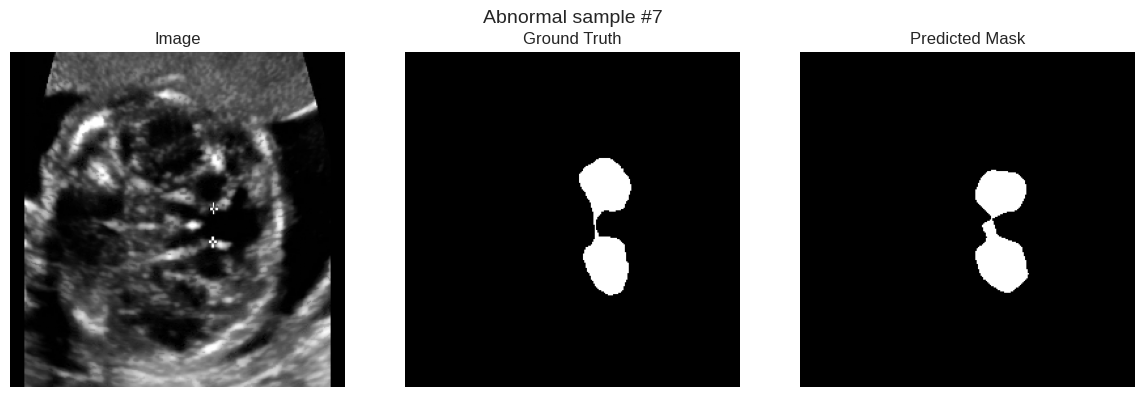

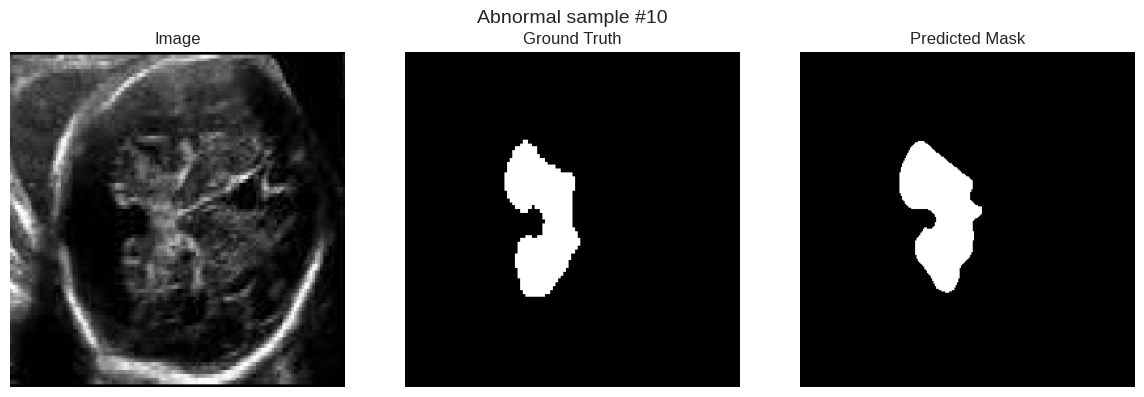

In [ ]:
# Show 3 random NORMAL test examples
#show_examples(model, Xn_test, yn_test, n=1, title_prefix="Normal")

# Show 3 random ABNORMAL (Dandy–Walker) test examples
show_examples(model, Xa_test, ya_test, n=15, title_prefix="Abnormal")


In [ ]:
loss, acc, prec, rec,Js,  dice = model.evaluate(test_normal_ds, verbose=1)

loss1, acc1, prec1, rec1,Js1, dice1 = model.evaluate(test_abn_ds, verbose=1)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy_metric: 0.9912 - dice_coefficient: 0.8654 - jaccard_index: 0.7659 - loss: 0.0311 - precision_metric: 0.8558 - recall_metric: 0.9210
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy_metric: 0.9813 - dice_coefficient: 0.7853 - jaccard_index: 0.6469 - loss: 0.0758 - precision_metric: 0.8152 - recall_metric: 0.7909


In [ ]:
"""
import tensorflow as tf
from tensorflow.keras import backend as K, layers, models
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings

# ==============================================================================
# 1. Custom Metrics and Architecture Definitions
# ==============================================================================

def dice_loss(y_true, y_pred):
    smooth = 1e-5
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return 1.0 - (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_coefficient(y_true, y_pred):
    smooth = 1.
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def jaccard_index(y_true, y_pred):
    smooth = 1.
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

def precision_metric(y_true, y_pred):
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
    return true_positives / (predicted_positives + K.epsilon())

def recall_metric(y_true, y_pred):
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
    return true_positives / (possible_positives + K.epsilon())

def accuracy_metric(y_true, y_pred):
    return K.metrics.accuracy(y_true, K.round(y_pred))

# ==============================================================================
# Blocks for model loading
# ==============================================================================

def dw_conv_ln_relu(x, filters, kernel_size=3, strides=1, dilation_rate=1):
    x = layers.DepthwiseConv2D(kernel_size, strides=strides, padding='same', dilation_rate=dilation_rate, use_bias=False)(x)
    x = layers.LayerNormalization(axis=-1)(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(filters, 1, padding='same', use_bias=False)(x)
    x = layers.LayerNormalization(axis=-1)(x)
    x = layers.ReLU()(x)
    return x

def shape_texture_block(x, filters):
    t = dw_conv_ln_relu(x, filters)
    s = layers.Lambda(lambda z: K.mean(z, axis=-1, keepdims=True))(x)
    sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype='float32').reshape((3,3,1,1))
    sobel_y = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype='float32').reshape((3,3,1,1))
    sx = layers.Conv2D(1, 3, padding='same', use_bias=False, trainable=False, kernel_initializer=tf.constant_initializer(sobel_x))(s)
    sy = layers.Conv2D(1, 3, padding='same', use_bias=False, trainable=False, kernel_initializer=tf.constant_initializer(sobel_y))(s)
    edge_mag = layers.Lambda(lambda z: tf.sqrt(z[0]**2 + z[1]**2 + 1e-6))([sx, sy])
    se = layers.Concatenate(axis=-1)([x, edge_mag])
    se = dw_conv_ln_relu(se, filters)
    out = layers.Concatenate(axis=-1)([t, se])
    out = layers.Conv2D(filters, 1, padding='same', use_bias=False)(out)
    out = layers.LayerNormalization(axis=-1)(out)
    out = layers.ReLU()(out)
    return out

def multi_scale_context_module(x, filters):
    b1 = dw_conv_ln_relu(x, filters, kernel_size=3, dilation_rate=1)
    b2 = dw_conv_ln_relu(x, filters, kernel_size=3, dilation_rate=3)
    b3 = dw_conv_ln_relu(x, filters, kernel_size=3, dilation_rate=5)
    gp = layers.GlobalAveragePooling2D()(x)
    gp = layers.Dense(filters, activation='relu')(gp)
    gp = layers.Dense(filters, activation='linear')(gp)
    gp = layers.Reshape((1, 1, filters))(gp)
    concat = layers.Concatenate(axis=-1)([b1, b2, b3, gp])
    out = layers.Conv2D(filters, 1, padding='same', use_bias=False)(concat)
    out = layers.LayerNormalization(axis=-1)(out)
    out = layers.ReLU()(out)
    return out

def attention_skip_fusion(dec, enc, filters):
    concat = layers.Concatenate(axis=-1)([dec, enc])
    gap = layers.GlobalAveragePooling2D()(concat)
    C_dec = int(dec.shape[-1])
    hidden = max(C_dec // 2, 8)
    a = layers.Dense(hidden, activation='relu')(gap)
    a = layers.Dense(C_dec, activation='sigmoid')(a)
    a = layers.Reshape((1, 1, C_dec))(a)
    dec_att = layers.Multiply()([dec, a])
    fused = layers.Concatenate(axis=-1)([dec_att, enc])
    fused = dw_conv_ln_relu(fused, filters)
    return fused

def channel_adapter(x, target_filters):
    x = layers.Conv2D(target_filters, 1, padding='same', use_bias=False)(x)
    x = layers.LayerNormalization(axis=-1)(x)
    x = layers.ReLU()(x)
    return x

def get_output_shape(layer):
    try:
        return layer.output_shape if hasattr(layer, 'output_shape') else layer.output.shape
    except:
        return None

# ==============================================================================
# Custom objects dictionary
# ==============================================================================

MY_CUSTOM_OBJECTS = {
    'dice_loss': dice_loss, 'jaccard_index': jaccard_index, 'dice_coefficient': dice_coefficient,
    'precision_metric': precision_metric, 'recall_metric': recall_metric, 'accuracy_metric': accuracy_metric,
    'dw_conv_ln_relu': dw_conv_ln_relu, 'shape_texture_block': shape_texture_block,
    'multi_scale_context_module': multi_scale_context_module, 'attention_skip_fusion': attention_skip_fusion,
    'channel_adapter': channel_adapter, 'get_output_shape': get_output_shape, 'tf': tf
}

# ==============================================================================
# NEW: Extract 5 samples from dataset
# ==============================================================================

def extract_dataset_to_numpy_multi(dataset, n_samples=5):
    data = list(dataset.unbatch().take(n_samples))
    X = np.stack([item[0].numpy() for item in data])
    y = np.stack([item[1].numpy() for item in data])
    return X, y

# ==============================================================================
# 2. Model and Data Setup
# ==============================================================================

model1_path = '/content/drive/MyDrive/Colab/PHD/Cerebellar/Methods/semi_model.h5'
model2_path = '/content/drive/MyDrive/Colab/PHD/Cerebellar/Methods/ECAUnet_model1.h5'
model3_path = '/content/drive/MyDrive/Colab/PHD/Cerebellar/Methods/Dual_CNN_model.h5'

my_model_object = None

if 'model' in locals() and isinstance(locals()['model'], tf.keras.Model):
    my_model_object = locals()['model']
    print("SUCCESS: Using model")
else:
    warnings.warn("No trained model found — using dummy model")
    input_shape = (256, 256, 3)
    dummy_inputs = tf.keras.layers.Input(input_shape)
    dummy_conv = tf.keras.layers.Conv2D(1, (1, 1), activation='sigmoid')(dummy_inputs)
    my_model_object = tf.keras.Model(inputs=dummy_inputs, outputs=dummy_conv)
    my_model_object.compile(optimizer='adam', loss=dice_loss)

# ==============================================================================
# Data Loading — NOW LOADS 5 SAMPLES
# ==============================================================================

data_loaded = False
X_test = np.array([])
y_test = np.array([])

if 'test_abn_ds' in locals():
    try:
        X_test, y_test = extract_dataset_to_numpy_multi(test_abn_ds, n_samples=5)
        data_loaded = True
        print("SUCCESS: Loaded 5 samples from dataset")
    except Exception as e:
        warnings.warn(f"Dataset error: {e}")

if not data_loaded or X_test.size == 0:
    print("WARNING: Creating DUMMY data (5 samples)")
    X_test = np.random.rand(5, 256, 256, 3).astype(np.float32)
    y_test = np.random.randint(0, 2, size=(5, 256, 256, 1)).astype(np.float32)

# ==============================================================================
# 3. Visualization Function
# ==============================================================================

def visualize_predictions(main_model_object, model1_path, model2_path, model3_path,
                          X_set, y_set, custom_objects_dict, num_samples=5):

    num_samples_to_display = min(num_samples, len(X_set))

    loaded_additional_models = []
    model_paths = [model1_path, model2_path, model3_path]
    model_names = ["FCRBUnet", "ECAUnet", "Dual_CNN"]
    loaded_names = []

    for i, path in enumerate(model_paths):
        name = model_names[i]
        if os.path.exists(path):
            try:
                m = tf.keras.models.load_model(path, custom_objects=custom_objects_dict)
                loaded_additional_models.append(m)
                loaded_names.append(name)
            except:
                pass

    predictions_main = main_model_object.predict(X_set[:num_samples_to_display], verbose=0)

    predictions_additional = [
        m.predict(X_set[:num_samples_to_display], verbose=0)
        for m in loaded_additional_models
    ]

    total_columns = 3 + len(loaded_additional_models)
    column_titles = ["Original", "Ground Truth", "My Model"] + loaded_names

    print(f"Generating plot with {num_samples_to_display} rows and {total_columns} columns.")
    plt.figure(figsize=(total_columns * 3, num_samples_to_display * 3))

    for i in range(num_samples_to_display):
        # Original
        plt.subplot(num_samples_to_display, total_columns, i * total_columns + 1)
        plt.imshow(X_set[i].squeeze(), cmap=None)
        plt.axis("off")
        if i == 0: plt.title(column_titles[0])

        # Ground truth
        plt.subplot(num_samples_to_display, total_columns, i * total_columns + 2)
        plt.imshow(y_set[i].squeeze(), cmap="gray")
        plt.axis("off")
        if i == 0: plt.title(column_titles[1])

        # Main model
        plt.subplot(num_samples_to_display, total_columns, i * total_columns + 3)
        plt.imshow((predictions_main[i].squeeze() > 0.5), cmap="gray")
        plt.axis("off")
        if i == 0: plt.title(column_titles[2])

        # Additional models
        for j, preds in enumerate(predictions_additional):
            plt.subplot(num_samples_to_display, total_columns, i * total_columns + 4 + j)
            plt.imshow((preds[i].squeeze() > 0.5), cmap="gray")
            plt.axis("off")
            if i == 0:
                plt.title(column_titles[3 + j])

    plt.tight_layout()
    plt.show()

# ==============================================================================
# 4. Run Visualization
# ==============================================================================

print("--- Starting Visualization Script ---")

visualize_predictions(
    main_model_object=my_model_object,
    model1_path=model1_path,
    model2_path=model2_path,
    model3_path=model3_path,
    X_set=X_test,
    y_set=y_test,
    num_samples=8,
    custom_objects_dict=MY_CUSTOM_OBJECTS
)
"""


'\nimport tensorflow as tf\nfrom tensorflow.keras import backend as K, layers, models\nimport numpy as np\nimport matplotlib.pyplot as plt\nimport os\nimport warnings\n\n# ==============================================================================\n# 1. Custom Metrics and Architecture Definitions\n# ==============================================================================\n\ndef dice_loss(y_true, y_pred):\n    smooth = 1e-5\n    y_true_f = K.flatten(y_true)\n    y_pred_f = K.flatten(y_pred)\n    intersection = K.sum(y_true_f * y_pred_f)\n    return 1.0 - (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)\n\ndef dice_coefficient(y_true, y_pred):\n    smooth = 1.\n    y_true_f = K.flatten(y_true)\n    y_pred_f = K.flatten(y_pred)\n    intersection = K.sum(y_true_f * y_pred_f)\n    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)\n\ndef jaccard_index(y_true, y_pred):\n    smooth = 1.\n    y_true_f = K.flatten(y_true)\n    

In [ ]:
"""
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# ------------------------------------------
# Function to generate the Grad-CAM heatmap
# ------------------------------------------
def get_segmentation_gradcam(model, img_array, target_class_index=None, target_layer_name=None):
    if target_layer_name is None:
        # Use last conv layer by default (you can set manually)
        target_layer_name = [layer.name for layer in model.layers if 'conv' in layer.name][-1]

    last_conv_layer = model.get_layer(target_layer_name)

    grad_model = tf.keras.models.Model(
        inputs=[model.input],
        outputs=[last_conv_layer.output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)

        if target_class_index is None:
            # Use the most active class channel (if multi-class)
            target_class_index = tf.argmax(tf.reduce_mean(predictions, axis=[1, 2]))  # (B, H, W, C) → scalar

        class_channel = predictions[..., target_class_index]  # (B, H, W)

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(1, 2))  # Average over H, W

    conv_outputs = conv_outputs[0]
    pooled_grads = pooled_grads[0]

    # Weighted combination of forward activation maps
    heatmap = tf.reduce_sum(tf.multiply(conv_outputs, pooled_grads), axis=-1)

    # ReLU and normalize
    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.reduce_max(heatmap) + 1e-10

    return heatmap.numpy()


# ------------------------------------------
# Overlay the heatmap on the original image
# ------------------------------------------
def display_heatmap(img_array, heatmap, alpha=0.4):
    heatmap = cv2.resize(heatmap, (img_array.shape[1], img_array.shape[0]))
    heatmap = np.uint8(255 * heatmap)

    # Apply colormap
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    # Normalize input image if needed
    if img_array.max() > 1:
        img_array = img_array / 255.0

    superimposed_img = heatmap / 255.0 * alpha + img_array
    superimposed_img = superimposed_img / superimposed_img.max()
    return np.uint8(255 * superimposed_img)


# ------------------------------------------
# Load and preprocess your image
# ------------------------------------------
def preprocess_image(img_path, target_size=(256, 256)):
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0  # Normalize
    return np.expand_dims(img_array, axis=0)  # Shape: (1, H, W, 3)


# ------------------------------------------
# Apply to a segmentation model
# ------------------------------------------
# Parameters
img_path = '/content/drive/MyDrive/Colab/PHD/Cerebellar/Cell_Dandy/image/10.png'
img_array = preprocess_image(img_path)


predictions = model.predict(img_array)
# Optional: choose class index manually (e.g., 0=background, 1=brain, etc.)
target_class_index = np.argmax(np.mean(predictions[0], axis=(0, 1)))

# Generate heatmap
heatmap = get_segmentation_gradcam(model, img_array, target_class_index)

# Load original image (for overlay)
original_img = cv2.imread(img_path)
original_img = cv2.resize(original_img, (img_array.shape[2], img_array.shape[1]))  # Resize to match

# Display
superimposed_img = display_heatmap(original_img / 255.0, heatmap)

# Plot
plt.figure(figsize=(12, 6))
fig, axarr = plt.subplots(1, 2, figsize=(14, 7))
for ax in axarr:
    ax.set_xticks([])
    ax.set_yticks([])
axarr[0].imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
axarr[0].set_title('Original Image', fontsize=15)
axarr[1].imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
axarr[1].set_title('Grad-CAM Heatmap Overlay', fontsize=15)
plt.tight_layout()
plt.show()

"""

"\nimport numpy as np\nimport tensorflow as tf\nimport cv2\nimport matplotlib.pyplot as plt\nfrom tensorflow.keras.preprocessing import image\n\n# ------------------------------------------\n# Function to generate the Grad-CAM heatmap\n# ------------------------------------------\ndef get_segmentation_gradcam(model, img_array, target_class_index=None, target_layer_name=None):\n    if target_layer_name is None:\n        # Use last conv layer by default (you can set manually)\n        target_layer_name = [layer.name for layer in model.layers if 'conv' in layer.name][-1]\n\n    last_conv_layer = model.get_layer(target_layer_name)\n\n    grad_model = tf.keras.models.Model(\n        inputs=[model.input],\n        outputs=[last_conv_layer.output, model.output]\n    )\n\n    with tf.GradientTape() as tape:\n        conv_outputs, predictions = grad_model(img_array)\n\n        if target_class_index is None:\n            # Use the most active class channel (if multi-class)\n            target_cl

In [ ]:
"""
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models, backend as K
from tensorflow.keras.preprocessing import image
import os

# ============================================================
# 1. ARCHITECTURE DEFINITION (Matches your model.h5 exactly)
# ============================================================

@tf.keras.utils.register_keras_serializable()
class ChannelMean(layers.Layer):
    def call(self, x): return K.mean(x, axis=-1, keepdims=True)

@tf.keras.utils.register_keras_serializable()
class EdgeMagnitude(layers.Layer):
    def __init__(self, eps=1e-6, **kwargs):
        super().__init__(**kwargs)
        self.eps = eps
    def call(self, inputs):
        sx, sy = inputs
        return tf.sqrt(tf.square(sx) + tf.square(sy) + self.eps)

def dw_conv_ln_relu(x, filters, kernel_size=3, strides=1, dilation_rate=1):
    x = layers.DepthwiseConv2D(kernel_size, strides=strides, padding='same',
                               dilation_rate=dilation_rate, use_bias=False)(x)
    x = layers.LayerNormalization(axis=-1)(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(filters, 1, padding='same', use_bias=False)(x)
    x = layers.LayerNormalization(axis=-1)(x)
    return layers.ReLU()(x)

def shape_texture_block(x, filters):
    t = dw_conv_ln_relu(x, filters)
    s = ChannelMean()(x)
    sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype='float32').reshape((3,3,1,1))
    sobel_y = np.array([[-1,-2,-1], [ 0, 0, 0], [ 1, 2, 1]], dtype='float32').reshape((3,3,1,1))
    sx = layers.Conv2D(1, 3, padding='same', use_bias=False, trainable=False,
                       kernel_initializer=tf.constant_initializer(sobel_x))(s)
    sy = layers.Conv2D(1, 3, padding='same', use_bias=False, trainable=False,
                       kernel_initializer=tf.constant_initializer(sobel_y))(s)
    edge_mag = EdgeMagnitude()([sx, sy])
    se = layers.Concatenate(axis=-1)([x, edge_mag])
    se = dw_conv_ln_relu(se, filters)
    out = layers.Concatenate(axis=-1)([t, se])
    out = layers.Conv2D(filters, 1, padding='same', use_bias=False)(out)
    out = layers.LayerNormalization(axis=-1)(out)
    return layers.ReLU()(out)

def multi_scale_context_module(x, filters):
    b1 = dw_conv_ln_relu(x, filters, dilation_rate=1)
    b2 = dw_conv_ln_relu(x, filters, dilation_rate=3)
    b3 = dw_conv_ln_relu(x, filters, dilation_rate=5)
    gp = layers.GlobalAveragePooling2D()(x)
    gp = layers.Dense(filters, activation='relu')(gp)
    gp = layers.Dense(filters)(gp)
    gp = layers.Reshape((1, 1, filters))(gp)
    # Resize global branch to match spatial dimensions
    gp = layers.Lambda(lambda x_in: tf.image.resize(x_in[0], [tf.shape(x_in[1])[1], tf.shape(x_in[1])[2]]))([gp, b1])
    concat = layers.Concatenate(axis=-1)([b1, b2, b3, gp])
    out = layers.Conv2D(filters, 1, padding='same', use_bias=False)(concat)
    out = layers.LayerNormalization(axis=-1)(out)
    return layers.ReLU()(out)

def attention_skip_fusion(dec, enc, filters):
    # Shape Guard: ensures encoder skip matches decoder resolution
    enc = layers.Lambda(lambda x_in: tf.image.resize(x_in[0], [tf.shape(x_in[1])[1], tf.shape(x_in[1])[2]]))([enc, dec])
    concat = layers.Concatenate(axis=-1)([dec, enc])
    gap = layers.GlobalAveragePooling2D()(concat)
    C_dec = int(dec.shape[-1])
    a = layers.Dense(max(C_dec // 2, 8), activation='relu')(gap)
    a = layers.Dense(C_dec, activation='sigmoid')(a)
    a = layers.Reshape((1, 1, C_dec))(a)
    dec_att = layers.Multiply()([dec, a])
    fused = layers.Concatenate(axis=-1)([dec_att, enc])
    return dw_conv_ln_relu(fused, filters)

def build_hybrid_cerdw_mobilenet(input_shape=(256, 256, 3)):
    inputs = layers.Input(shape=input_shape)
    backbone = tf.keras.applications.MobileNetV3Small(input_shape=input_shape, include_top=False, weights=None)

    # Encoder Skip Extraction (Verified Indices)
    skip_indices = [8, 16, 40, 80, 152]
    skips = [backbone.layers[i].output for i in skip_indices]
    e1_mob, e2_mob, e3_mob, e4_mob, bottleneck = skips

    # Adaptation
    e1, e2, e3, e4 = [layers.Conv2D(f, 1, padding='same')(s) for f, s in zip([24, 32, 48, 64], [e1_mob, e2_mob, e3_mob, e4_mob])]
    x = layers.Conv2D(96, 1, padding='same')(bottleneck)
    b = multi_scale_context_module(x, 96)

    # Decoder
    def up_stage(curr, skip, f):
        curr = layers.UpSampling2D((2, 2), interpolation='bilinear')(curr)
        curr = attention_skip_fusion(curr, skip, f)
        return shape_texture_block(curr, f)

    d = up_stage(b, e4, 64)   # 8->16
    d = up_stage(d, e3, 48)   # 16->32
    d = up_stage(d, e2, 32)   # 32->64
    d = up_stage(d, e1, 24)   # 64->128

    d = layers.UpSampling2D((2, 2), interpolation='bilinear')(d)
    d = dw_conv_ln_relu(d, 24)
    outputs = layers.Conv2D(1, 1, activation='sigmoid', name='segmentation_output')(d)
    return models.Model(inputs=backbone.input, outputs=outputs)

# ============================================================
# 2. INTEGRATED GRADIENTS (IG) LOGIC
# ============================================================

def integrated_gradients(model, img_input, baseline=None, steps=50):
    if baseline is None:
        baseline = tf.zeros_like(img_input)

    # Generate linear interpolations between baseline and input
    alphas = tf.linspace(0.0, 1.0, steps + 1)
    # We use a loop to avoid OOM (Out Of Memory) issues on larger steps
    total_grads = tf.zeros_like(img_input)

    for alpha in alphas:
        interpolated = baseline + alpha * (img_input - baseline)
        with tf.GradientTape() as tape:
            tape.watch(interpolated)
            pred = model(interpolated)
            # Target the sum of the predicted mask (measures 'object presence')
            score = tf.reduce_sum(pred)

        grads = tape.gradient(score, interpolated)
        total_grads += grads

    # Average gradients and multiply by (input - baseline)
    avg_grads = total_grads / len(alphas)
    ig = (img_input - baseline) * avg_grads

    # Reduce to 2D heatmap (sum across color channels)
    attribution = tf.reduce_sum(tf.abs(ig), axis=-1).numpy()[0]
    return attribution

# ============================================================
# 3. LOAD, PREDICT, AND RESULT
# ============================================================

# Configuration
weights_path = "/content/drive/MyDrive/Colab/PHD/Cerebellar/model.h5"
img_path = '/content/drive/MyDrive/Colab/PHD/Cerebellar/Cell_Dandy/image/10.png'

# 1. Setup Model
model = build_hybrid_cerdw_mobilenet()
model.load_weights(weights_path, by_name=True, skip_mismatch=True)
print("✅ Architecture Rebuilt and Weights Loaded.")

# 2. Prepare Image
raw_img = cv2.imread(img_path)
raw_img = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)
raw_img = cv2.resize(raw_img, (256, 256))
img_tensor = np.expand_dims(raw_img.astype(np.float32) / 255.0, axis=0)

# 3. Predict Mask and IG
mask_pred = model.predict(img_tensor, verbose=0)[0, ..., 0]
ig_attribution = integrated_gradients(model, img_tensor, steps=50)

# 4. Final Result Visualization
# Normalize IG for visualization
ig_viz = (ig_attribution - ig_attribution.min()) / (ig_attribution.max() - ig_attribution.min() + 1e-10)

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(raw_img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask_pred, cmap='gray')
plt.title("Model Prediction (Mask)")
plt.axis("off")

plt.subplot(1, 3, 3)
# Overlay IG on grayscale original for context
plt.imshow(cv2.cvtColor(raw_img, cv2.COLOR_RGB2GRAY), cmap='gray', alpha=0.5)
plt.imshow(ig_viz, cmap='hot', alpha=0.7)
plt.title("Integrated Gradients (Pixel Importance)")
plt.axis("off")

plt.tight_layout()
plt.show()
"""

'\nimport numpy as np\nimport tensorflow as tf\nimport cv2\nimport matplotlib.pyplot as plt\nfrom tensorflow.keras import layers, models, backend as K\nfrom tensorflow.keras.preprocessing import image\nimport os\n\n# ============================================================\n# 1. ARCHITECTURE DEFINITION (Matches your model.h5 exactly)\n# ============================================================\n\n@tf.keras.utils.register_keras_serializable()\nclass ChannelMean(layers.Layer):\n    def call(self, x): return K.mean(x, axis=-1, keepdims=True)\n\n@tf.keras.utils.register_keras_serializable()\nclass EdgeMagnitude(layers.Layer):\n    def __init__(self, eps=1e-6, **kwargs):\n        super().__init__(**kwargs)\n        self.eps = eps\n    def call(self, inputs):\n        sx, sy = inputs\n        return tf.sqrt(tf.square(sx) + tf.square(sy) + self.eps)\n\ndef dw_conv_ln_relu(x, filters, kernel_size=3, strides=1, dilation_rate=1):\n    x = layers.DepthwiseConv2D(kernel_size, strides=stride

# **Score_CAM**

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt



def normalize_0_1(x):
    x = x - np.min(x)
    return x / (np.max(x) + 1e-8)

def overlay_cam(image, cam, alpha=0.45):
    cam_rgb = plt.cm.jet(cam)[..., :3]
    return np.clip((1 - alpha) * image + alpha * cam_rgb, 0, 1)




def seg_score(pred_mask, thr=0.5):
    pm = pred_mask.squeeze()
    region = (pm > thr).astype(np.float32)
    if region.sum() < 10:
        return float(pm.mean())
    return float((pm * region).sum() / (region.sum() + 1e-8))



def seg_score_gt(pred_mask, y_true):
    pm = pred_mask.squeeze()
    gt = y_true.squeeze().astype(np.float32)
    if gt.sum() < 10:
        return float(pm.mean())
    return float((pm * gt).sum() / (gt.sum() + 1e-8))






def score_cam_segmentation(
    model,
    image,
    target_layer,
    y_true=None,
    max_maps=32,
    thr=0.5
):
    H, W, C = image.shape

    # Model that outputs feature maps + prediction
    cam_model = tf.keras.Model(
        model.inputs,
        [model.get_layer(target_layer).output, model.output]
    )

    img_batch = tf.expand_dims(tf.convert_to_tensor(image, tf.float32), 0)
    fmap, pred = cam_model(img_batch, training=False)

    fmap = fmap[0].numpy()          # (h,w,k)
    pred_mask = pred[0].numpy()     # (H,W,1)

    h, w, k = fmap.shape

    # Select most active maps (better than variance)
    idxs = np.argsort(
        np.mean(fmap.reshape(-1, k), axis=0)
    )[::-1][:min(max_maps, k)]

    # Baseline score
    if y_true is None:
        base = seg_score(pred_mask, thr)
    else:
        base = seg_score_gt(pred_mask, y_true)

    cam = np.zeros((H, W), dtype=np.float32)

    for i in idxs:
        m = np.maximum(fmap[..., i], 0)
        if np.max(m) < 1e-8:
            continue

        m = normalize_0_1(m)
        m_up = tf.image.resize(
            m[..., None], (H, W), method="bilinear"
        ).numpy()[..., 0]

        masked = image * m_up[..., None]
        masked_pred = model(
            tf.expand_dims(masked, 0), training=False
        )[0].numpy()

        if y_true is None:
            score = seg_score(masked_pred, thr)
        else:
            score = seg_score_gt(masked_pred, y_true)

        weight = max(0.0, score - base)
        cam += weight * m_up

    cam = normalize_0_1(np.maximum(cam, 0))
    return cam, pred_mask


In [ ]:
def show_all_one_line(image, y_true, pred_mask, cam, thr=0.5):
    pm = pred_mask.squeeze()
    pm_bin = (pm > thr).astype(np.float32)
    gt = y_true.squeeze()

    overlay = overlay_cam(image, cam)

    fig, axs = plt.subplots(1, 5, figsize=(22, 4))

    axs[0].imshow(image)
    axs[0].set_title("Input")

    axs[1].imshow(gt, cmap="gray")
    axs[1].set_title("GT")

    axs[2].imshow(pm_bin, cmap="gray")
    axs[2].set_title("Pred")

    axs[3].imshow(cam, cmap="jet")
    axs[3].set_title("Score-CAM")

    axs[4].imshow(overlay)
    axs[4].contour(pm_bin, levels=[0.5], colors="red", linewidths=2)
    axs[4].set_title("Overlay + Contour")

    for ax in axs:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


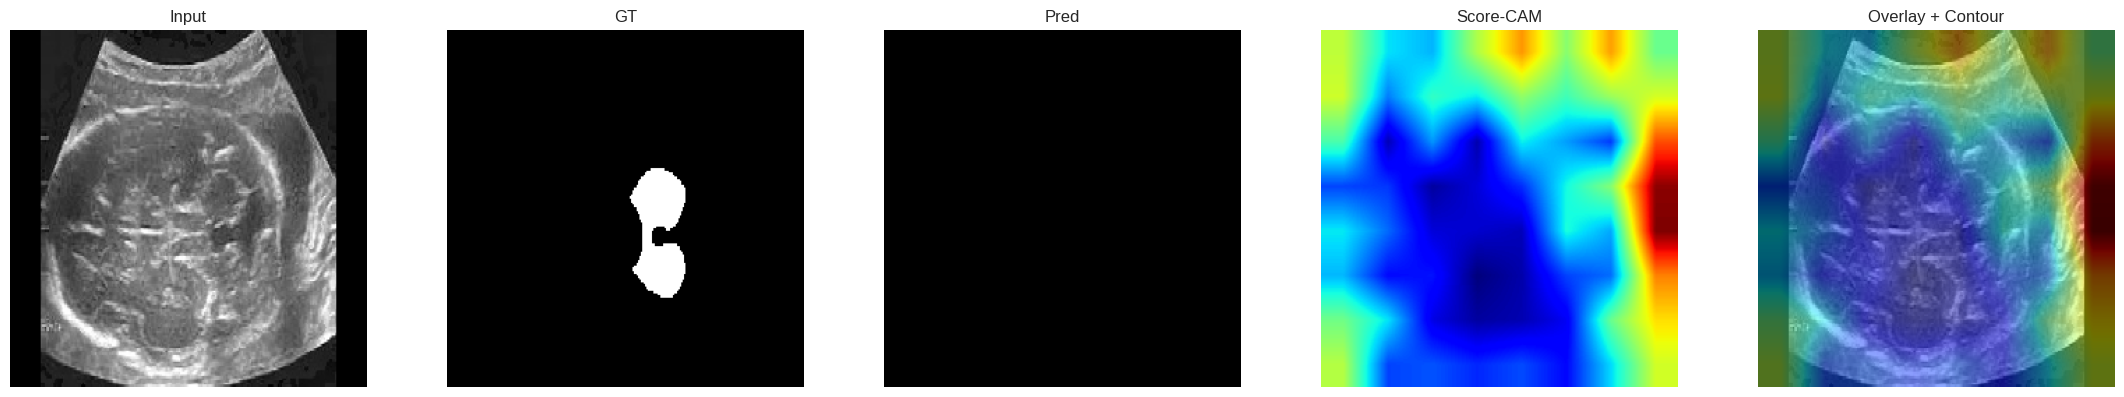

In [34]:
TARGET_LAYER = "re_lu_81"

img_path = '/content/drive/MyDrive/Colab/PHD/few-shot/Cerebellar/Cell_Dandy/image/1.png'
gr_path = '/content/drive/MyDrive/Colab/PHD/few-shot/Cerebellar/Cell_Dandy/ground-truth/1.png'



raw_img = cv2.imread(img_path, cv2.IMREAD_COLOR)
raw_img = cv2.resize(raw_img, (256, 256))
raw_img = mlvum(raw_img, neighborhood_size=15, k=0)
raw_img = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)
raw_img = raw_img.astype(np.float32) / 255.0

raw_gt = cv2.imread(gr_path, cv2.IMREAD_GRAYSCALE)
gt = cv2.resize(raw_gt, (256, 256), interpolation=cv2.INTER_NEAREST)
gt = (gt > 127).astype(np.float32)
gt = np.expand_dims(gt, axis=-1)


# compute cam + prediction
cam, pred_mask = score_cam_segmentation(
    model=model,
    image=raw_img,
    target_layer=TARGET_LAYER,
    y_true=gt,
    max_maps=64,
    thr=0.5
)

# show all results in one line
show_all_one_line(raw_img, gt, pred_mask, cam, thr=0.5)
